# Estimación espectral no-paramétrica: LIGO

**22.46 Procesamiento Adaptativo de Señales Aleatorias — Trabajo Práctico 1**

---

# Grupo N° 5

| Integrante | Legajo |
|---|---|
| Albertine Gjøs | 69531 |
| Marek Myrebøe-Engels | 69476 |

**Fecha de entrega:** 08/09

---

> **Cómo se entrega.** Este notebook **es** el informe. Completen la portada de arriba,
> resuelvan cada inciso en su sección correspondiente **sin alterar el orden ni la numeración**,
> y dejen en cada celda de respuesta la justificación escrita: las decisiones de parametrización
> son el contenido evaluado, no un detalle de implementación.
>
> Entreguen el notebook **ejecutado de principio a fin y guardado con las salidas visibles**,
> con el nombre `TP1_LIGO_Grupo<N>.ipynb`. Usen rutas relativas a `data/` y **no incluyan los archivos de datos**
> en la entrega. El notebook debe correr de arriba a abajo sin intervención manual.

## Presentación

En este trabajo deberán analizar la onda gravitatoria **GW150914**, la primera detección directa de la historia. Fue registrada por el proyecto **LIGO** (Laser Interferometer Gravitational-Wave Observatory) el 14 de septiembre de 2015, y corresponde a la fusión de dos agujeros negros de 36 y 29 masas solares a unos 1300 millones de años luz.

El interés para esta materia es instrumental: **la señal llega enterrada bajo un ruido que la supera ampliamente, sobre un instrumento cuyo espectro abarca varias décadas de amplitud**. Todo el trabajo consiste en estimar bien ese ruido y usar esa estimación para recuperar la señal.

### Los detectores

Cada detector es un interferómetro de Michelson con brazos de 4 km y cavidades Fabry-Perot. Lo que mide es la **deformación** relativa del espacio, o *strain*:

$$h(t) = \frac{\Delta L(t)}{L}$$

Para GW150914 el pico fue $h \approx 10^{-21}$: un cambio de longitud de brazo de $4 \times 10^{-18}\,\mathrm{m}$, cuatro órdenes de magnitud por debajo del diámetro de un protón. Tengan presente esa cifra cuando evalúen qué tan cerca del ruido está lo que buscan.

Hay dos detectores, en Hanford (Washington) y en Livingston (Louisiana), separados por $d = 3002\,\mathrm{km}$. Como las ondas gravitatorias viajan a la velocidad de la luz, el retardo entre ambos está acotado por

$$\Delta t_{\max} = \frac{d}{c} \approx 10\,\mathrm{ms}$$

En la notación de GWOSC, **H1** es Hanford y **L1** es Livingston.

### El ruido de fondo

La sensibilidad está limitada por varias contribuciones simultáneas, cada una dominante en una región distinta del espectro:

<img src="ligo_noise.png" alt="LIGO Noise" width="400px"/>

**Atención: es una curva de diseño esquemática, no una medición.** Indica qué mecanismos limitan la sensibilidad y dónde domina cada uno, pero los niveles absolutos no corresponden al instrumento con el que van a trabajar.

A esto se suman **componentes tonales**: modos mecánicos de las suspensiones, líneas de red y sus armónicas, líneas inyectadas para calibración, resonancias de la óptica.

### El set de datos

Los datos son públicos y están en **GWOSC** (Gravitational Wave Open Science Center): [gwosc.org/events/GW150914](https://gwosc.org/events/GW150914/)

Descarguen los datos de *strain* a **4096 Hz** para H1 y L1. Para cada detector hay dos archivos HDF5:

| Archivo | Duración | Uso previsto |
|---|---|---|
| Ventana corta centrada en el evento | 32 s | Whitening y DOA (puntos 3 y 4) |
| Ventana larga | 4096 s | Espectro de ruido (punto 2) |

Los nombres siguen el patrón `<D>-<D1>_LOSC_4_V2-<GPS_inicio>-<duración>.hdf5`, por ejemplo `H-H1_LOSC_4_V2-1126259446-32.hdf5`.

El evento es una señal de tipo **chirp** que ocurre cerca del tiempo GPS $1126259462{,}4\,\mathrm{s}$ y dura aproximadamente $200\,\mathrm{ms}$. Puede verse y escucharse en [este video](https://www.youtube.com/watch?v=QyDcTbR-kEA).
### Notas de implementación

- **Grafiquen siempre en escala log-log.** Con este rango dinámico, un gráfico lineal no muestra nada.
- Es habitual reportar la **amplitud** espectral $\sqrt{S_x(f)}$ en $1/\sqrt{\mathrm{Hz}}$ en lugar de la potencia. Elijan una convención y sean consistentes.
- Verifiquen la **normalización** de sus estimadores: una PSD mal escalada por el factor de la ventana pasa desapercibida en escala logarítmica pero arruina el whitening.
- Usen `sosfiltfilt` en lugar de `lfilter`: un corrimiento de fase entre H1 y L1 destruiría la estimación de retardo del punto 4.
- Documenten **todas** las decisiones de parametrización ($N$, $L$, $K$, ventana, solapamiento, banda) y su justificación.

> **Sobre el Anexo.** Al final de este notebook hay un anexo con valores publicados por la colaboración LIGO, dentro de una sección plegada. **Ábranlo recién después de haber producido sus propios resultados**, y usen la comparación como material de discusión.

## 0. Preparación

Celda de configuración común. Ajusten `DATA` si sus archivos están en otro lado.

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import h5py                              # lectura de los HDF5 de GWOSC
from pathlib import Path
from scipy.signal import welch, periodogram, correlate
from scipy.signal import butter, sosfiltfilt
from scipy.signal.windows import tukey, hann
from scipy.interpolate import interp1d
from scipy.io import wavfile             # exportación del audio

DATA = Path("data")                      # carpeta con los .hdf5 descargados de GWOSC
FS = 4096                                # Hz
GPS_EVENTO = 1126259462.4                # s


def leer_strain(path):
    """Devuelve (strain, t0, dt) de un archivo de strain de GWOSC."""
    with h5py.File(path, "r") as f:
        strain = f["strain"]["Strain"][:]
        t0 = f["strain"]["Strain"].attrs["Xstart"]
        dt = f["strain"]["Strain"].attrs["Xspacing"]
    return strain, t0, dt


plt.rcParams["figure.figsize"] = (10, 4)

---

## 1. Investigación preliminar

Investiguen cómo funcionan los detectores de LIGO y escriban un resumen breve que cubra los mecanismos físicos que limitan la sensibilidad y en qué banda domina cada uno, qué tipo de artefactos aparecen en los datos (líneas espectrales, transitorios, no estacionariedad) y qué rango dinámico esperan encontrar en la amplitud espectral.

> **Resumen.**
>
> **Mecanismos Físicos Limitantes**
> - **Ruido Sísmico y de Suspención (<20Hz)**: Vibraciones terrestres y movimiento de la estructura de suspensión de los espejos.
> - **Ruido térmico (50–100 Hz)**: Movimiento browniano de los componentes mecánicos (espejos y suspensiones).
> - **Ruido cuántico (> 70 Hz)**: Limitaciones fundamentales de efectos cuánticos a frecuencias altas.
> - **Ruido newtoniano (< 20 Hz)**: Fluctuaciones en el campo gravitacional local.
>
> **Artefactos Espectrales y Transitorios**
> - **Líneas espectrales**: Picos causados por resonancias mecánicas, armónicos de la red eléctrica (50/60 Hz), y señales de calibración.
> - **Transitorios**: Ráfagas de ruido impulsivo por eventos ambientales (terremotos, tormentas, movimiento del terreno).
> - **No estacionariedad**: Variaciones temporales en el nivel de ruido a lo largo del tiempo.
>
> **Rango Dinámico Esperado**
> - Amplitud espectral de ruido: ~10⁻²³ Hz⁻¹/² en la banda más sensible (100–300 Hz).
> - Amplitud de la señal GW150914: Δh ~ 10⁻²¹ (pico), dos órdenes de magnitud sobre el ruido.


---

## 2. Estimación del espectro de ruido

Estimen el espectro de potencia del ruido de H1 y L1 usando las partes de la señal que **no** involucran el evento. Justifiquen qué tramo excluyeron.

### 2.a — Periodograma

Estímenlo con el **periodograma**. Seleccionen y justifiquen la cantidad de datos $N$.

C:\Users\alber\AppData\Roaming\Python\Python312\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\alber\AppData\Roaming\Python\Python312\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Periodogram (scipy)')

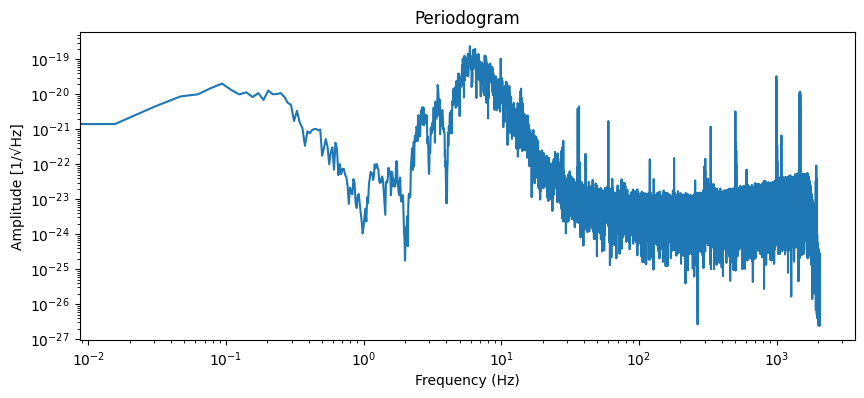

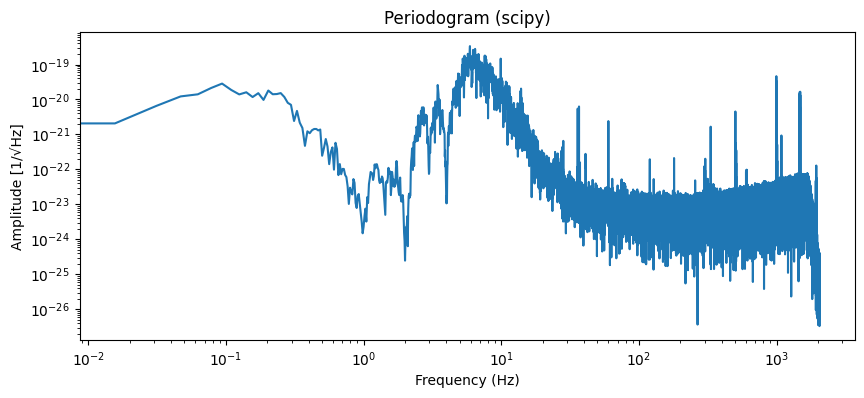

In [50]:

H1_long_path = DATA / "H-H1_LOSC_4_V2-1126257414-4096.hdf5"
#L1_long_path = "L-L1_LOSC_4_V2-1126257414-4096.hdf5"
strain, t0, dt = leer_strain(H1_long_path)

# Convert GPS time to index in array
event_start_continous = GPS_EVENTO - t0
event_start_discrete = int(event_start_continous * FS) # n = t*Fs

event_end_continous = event_start_continous + 0.2
event_end_discrete = int(event_end_continous * FS)

# Adds buffer
buffer = int(0.5 * FS) # 500ms buffer on each side
event_start_index = event_start_discrete - buffer
event_end_index = event_end_discrete + buffer

# Get clean nois (no event) (everything before and after)
noise = np.concatenate([strain[:int(event_start_index)], strain[int(event_end_index):]])

# Periodogram
N = 262144
f = np.fft.fftfreq(N, 1/FS)[:N//2] # Frequency in Hz

x = noise[:N] # Need to be of same size as the window
window = hann(N)
v = x * window 

V = np.fft.fft(v)
U = np.sum(window**2)  # window power, for normalization
R_x = (V * np.conj(V) / (FS*U))[:N//2] # Normalization corrects for energy loss due to the window

plt.figure()
plt.loglog(f, np.sqrt(R_x))  # amplitude spectral density
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude [1/√Hz]')
plt.title('Periodogram')

# Short version
window = 'hann'
f_hat, R_x_hat = periodogram(noise, fs=FS, window=window, nfft=N, scaling='density')
plt.figure()
plt.loglog(f_hat, np.sqrt(R_x_hat))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude [1/√Hz]')
plt.title('Periodogram (scipy)')


> **Respuesta.** *(completar)*
Debido al rango dinámico grande el periodograma con la ventana rectangular no sirve. Tiene demasiado leakage espectral y este va a romper la estimación. Probamos con Hann y Hamming en lugar del periodograma no modificado. Tukey posible


El N::........
Aumentamos N -> aumentará la resolución, pero no disminuirá la varianza. deltaf = fs/N
Small N (e.g., 4,096): Coarse view, can't see narrow spectral lines, but fast
Large N (e.g., 262,144): Fine-grained view of spectral structure, but each point is still noisy
Even larger N doesn't help—the noise doesn't go away

N = 4,096 → Δf = 1 Hz (coarse)
N = 65,536 → Δf = 0.0625 Hz (fine)
N = 262,144 → Δf = 0.0156 Hz (very fine)

If N is too small	If N is too large
Can't resolve fine spectral features (lines, resonances)	Slower computation, need more clean data
Lose the thermal noise structure	Over-smooths in frequency domain

For LIGO, you want to resolve narrow spectral features (power line harmonics at 60 Hz, 120 Hz, 180 Hz, etc.). So:

If N = 4,096: Δf = 1 Hz (can't resolve 60 Hz line structure well)
If N = 262,144: Δf = 0.0156 Hz (can resolve details within the 60 Hz line)

### 2.b — Periodogram smoothing

Estímenlo con **periodogram smoothing**. Seleccionen y justifiquen $N$ y $L$. Iteren hasta obtener una buena estimación.

Text(0.5, 1.0, 'Periodogram Smoothing')

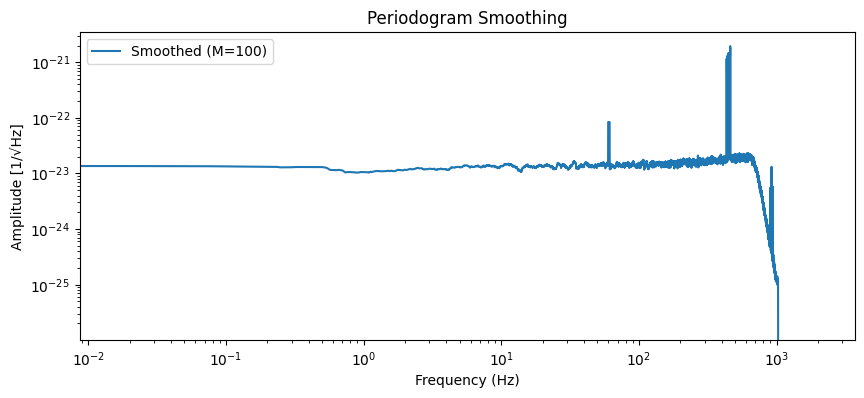

In [51]:
# Using N // 2 because only considering the positive frequencies
M = 100 # smoothing parameter (Number of bins to average)
W = np.zeros(N//2)
W[:M] = 1/M # rectangular window in frequency domain with area 1

R_x_PS = np.convolve(R_x, W, mode="same") # mode keeps output the same size as R_x

plt.loglog(f, np.sqrt(R_x_PS), label=f'Smoothed (M={M})')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude [1/√Hz]')
plt.title('Periodogram Smoothing')




> **Respuesta.** *(completar)*

Different Ms: 
Try different M values to see the trade-off:

M = 10: Minimal smoothing, keeps detail but noisy
M = 100: Good balance
M = 500: Heavy smoothing, very clean but loses features

### 2.c — Periodogram averaging

Estímenlo con **periodogram averaging**. Seleccionen y justifiquen $N$, $K$ y $L$. Iteren hasta obtener una buena estimación.

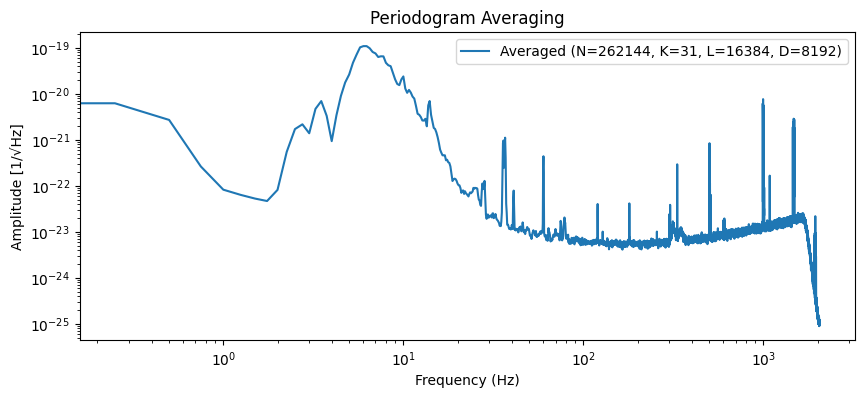

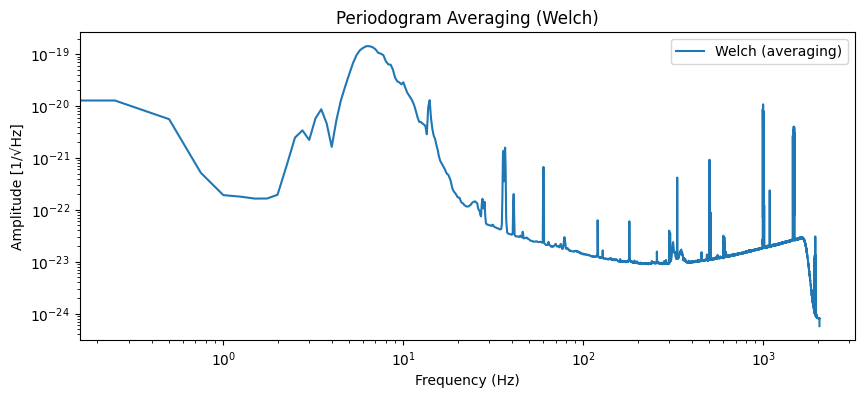

In [52]:
L = 16384 # Length of each segment
D = int(L/2)# Stride between segments (50% overlap)

# Calculate K (Total number of segments that fit into the signal)
K = int((N - L) // D + 1) 

window = hann(L)
window_scale = 1.0 / (FS * np.sum(window**2)) # Using higher up as well, just by different name (U)

# Loop through the K segments and compute their periodograms
psd_list = []

for k in range(K):
    # Determine start index for the current segment k
    start_idx = k * D
    end_idx = start_idx + L
    
    # Extract segment k
    segment = x[start_idx:end_idx]
    
    # Detrend (remove mean) and applay the window
    segment = (segment - np.mean(segment)) * window
    
    # Compute the Real FFT (one-sided)
    fft_vals = np.fft.rfft(segment)
    psd_segment = (np.abs(fft_vals) ** 2) * window_scale
    
    psd_list.append(psd_segment)

R_x_PA = psd_averaged = np.mean(psd_list, axis=0)
f = np.fft.rfftfreq(L, 1/FS)

plt.figure()
plt.loglog(f, np.sqrt(R_x_PA), label=f'Averaged (N={N}, K={K}, L={L}, D={D})')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude [1/√Hz]')
plt.title('Periodogram Averaging')

# SHort version
f_hat, R_x_PA_hat = welch(noise, fs=FS, window='hann', nperseg=L, noverlap=D, scaling='density')
plt.figure()
plt.loglog(f_hat, np.sqrt(R_x_PA_hat), label='Welch (averaging)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude [1/√Hz]')
plt.title('Periodogram Averaging (Welch)')
plt.legend()


> **Respuesta.** *(completar)*

50 % overlapp gives

K : el promedio disminuye la varianza de las estimaciones en 1/K. (El factor de reducción de varianza del periodogram averaging es 1/K)
El tipo de ventana no afecta la varianza. En la práctica, un overlap de hasta el 50% ayuda a disminuir la varianza. Con un overlap mayor \, la varianza no disminuye significativamente porque aumenta la correlación entre segmentos. 

Should be L ≈ 16384 to 65536 (4-16 seconds per segment)

### 2.d — Comparación de métodos

Determinen y justifiquen cuál de los tres produce la mejor estimación, discutiendo el compromiso entre resolución, sesgo y varianza. Incluyan en la discusión la elección de la **ventana**: dado el rango dinámico de este problema, comparen al menos una ventana con *taper* contra la rectangular.

> **Respuesta.** *(completar)*

Periodogram Smoothing (2.b):

Starts with N = 262,144 (Δf ≈ 0.0156 Hz very fine resolution)
Smooths it with M = 100 bin average
Result: High resolution but still noisy
Periodogram Averaging (2.c):

Splits into K segments of L = 16,384 each (Δf ≈ 0.25 Hz coarser)
Averages K independent periodograms
Result: Lower resolution but much cleaner (variance reduced by 1/K)
The Trade-off
Method	Resolution	Variance	Smoothness
Smoothing (2.b)	Very high (0.0156 Hz)	Still moderate	Moderate
Averaging (2.c)	Lower (0.25 Hz)	Very low (×1/K)	Very smooth


### 2.e — H1 contra L1

Comparen las estimaciones de H1 y L1 entre sí: picos espectrales, artefactos, sesgo, varianza y cualquier otra cosa que les llame la atención. Atribuyan un origen a las componentes tonales que encuentren. ¿Cómo se compara lo que midieron con la curva esquemática de la presentación?

> **Respuesta.** *(completar)*
Both detectors have similar broad noise structure (same fundamental physics: seismic, thermal, quantum noise)
But different specific artifacts (local electromagnetic interference, different mechanical resonances, environmental conditions specific to each location—Hanford vs Livingston are ~3000 km apart)


### 2.f — Estacionariedad

**Validen la estacionariedad** de las señales. Investiguen técnicas de validación y aplíquenlas. ¿Sobre qué horizonte temporal es razonable tratar el ruido como estacionario?

'\n    f_block, psd_block = welch(\n        block,\n        fs=FS,\n        window="hann",\n        nperseg=16384,\n        noverlap=8192,\n        scaling="density"\n    )\n\n    band = (f_block >= 100) & (f_block <= 300)\n    band_powers.append(np.mean(psd_block[band]))\n    \naxes[2].plot(band_powers, "o-")\naxes[2].set_ylabel("Mean PSD\n100–300 Hz")\naxes[2].set_xlabel("Block number")\n    \n'

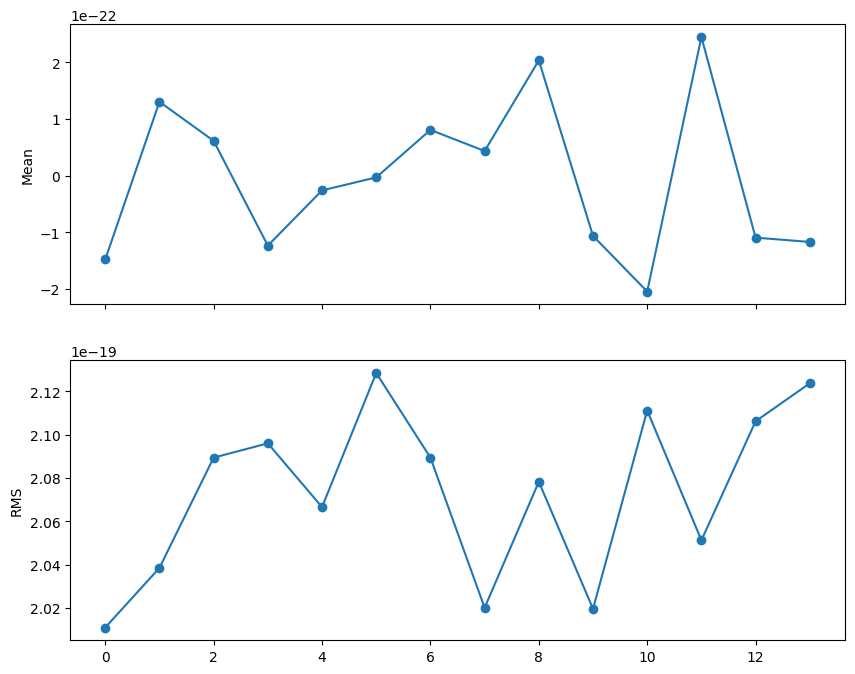

In [53]:
# Using consecutive blocks from the original strain
# Using the original strain to not join the data from before and after the event
block_length = 256 * FS # 256 seconds per block
n_blocks = len(strain) // block_length

means = []
rms_values = []
band_powers = []

for k in range(n_blocks):
    start = k * block_length
    stop = start + block_length
    block = strain[start:stop]
    
    # Skip blocks containing the event and its safety buffer
    if start < event_end_index and stop > event_start_index: 
        continue
    
    means.append(np.mean(block))
    rms_values.append(np.std(block))


fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(means, "o-")
axes[0].set_ylabel("Mean")

axes[1].plot(rms_values, "o-")
axes[1].set_ylabel("RMS")
    

# Could also plot frequencies, but dont know why we would need it: 
"""
    f_block, psd_block = welch(
        block,
        fs=FS,
        window="hann",
        nperseg=16384,
        noverlap=8192,
        scaling="density"
    )

    band = (f_block >= 100) & (f_block <= 300)
    band_powers.append(np.mean(psd_block[band]))
    
axes[2].plot(band_powers, "o-")
axes[2].set_ylabel("Mean PSD\n100–300 Hz")
axes[2].set_xlabel("Block number")
    
"""
    


> **Respuesta.** *(completar)*
Does the noise statistics remain approximately constant over time, for how long is this assumption reasonable

Divide the long H1 noise record into consecutive time blocks.
Compare their statistics:
mean,
variance or RMS,
PSD in selected frequency bands.
Decide whether the spectra remain sufficiently similar.
Estimate a reasonable stationarity horizon, such as seconds, minutes, or hours.

---

## 3. Whitening

Con la mejor estimación del punto 2, realicen el **whitening** de los 32 s alrededor del evento: en el dominio de la frecuencia, normalicen cada componente por la amplitud espectral del ruido. Referencia útil: [los tutoriales de GWOSC](https://gwosc.org/tutorials/).

In [ ]:
# Using the best periodogram (the one with averaging) (go back and test with tukey window as well)
f_noise, psd_noise = welch(noise, fs=FS, window='hann', nperseg=L, noverlap=D, scaling='density')

H1_short_path = DATA / "H-H1_LOSC_4_V2-1126259446-32.hdf5"
strain_short, t0_short, dt_short = leer_strain(H1_short_path)

# FFT of the event data
n_event = len(strain_short)
frequencies_event = np.fft.rfftfreq(n_event, d=1/FS)
spectrum_event = np.fft.rfft(strain_short)


# Put the PSD on the event FFt frequency grid (I THINK IT IS IMPORTED AN interp1d or something I should maybe use instead)
psd_event = np.interp(frequencies_event, f_noise, psd_noise)

# Avoid division by zero
psd_event = np.maximum(psd_event, np.finfo(float).tiny)

# Frequency-domain whitening
whitened_spectrum = spectrum_event / np.sqrt(psd_event)
whitened_h1 = np.fft.irfft(whitened_spectrum, n=n_event)

# Remove numerical DC offset and normalize only for plotting
whitened_h1 -= np.mean(whitened_h1)
whitened_h1 /= np.std(whitened_h1)


> **Whitening.** *(completar)*

Is it the inversion type of adaptive filter that is whitening? And is that what I am going to do in task 3? and can I use any of the imported functions?

### 3.a — Filtrado y visualización

Filtren pasabanda en la región de mayor sensibilidad, justificando los límites a partir de sus estimaciones del punto 2, y grafiquen la señal en el tiempo para ambos detectores. Deberían ver el chirp.

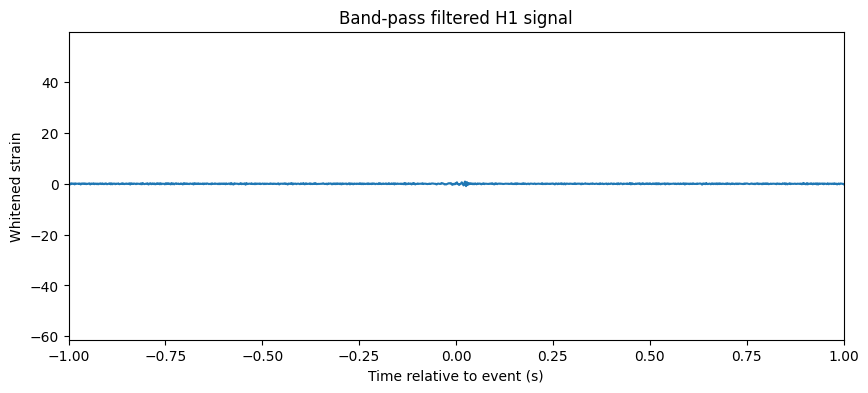

In [56]:
sos = butter(4, [35, 300], btype="bandpass", fs=FS, output="sos")

filtered_h1 = sosfiltfilt(sos, whitened_h1)
t_event = np.arange(len(filtered_h1)) / FS + t0_short - GPS_EVENTO # Centraizing the event

plt.figure()
plt.plot(t_event, filtered_h1)
plt.xlabel("Time relative to event (s)")
plt.ylabel("Whitened strain")
plt.title("Band-pass filtered H1 signal")
plt.xlim(-1, 1)
plt.show()


> **Respuesta.** *(completar)*

[35, 300] Hz: GW150914 sweeps approximately from 35 to 250 Hz. Frequencies below 35 Hz are dominated by seismic and suspension noise, while frequencies above roughly 300 Hz contain less of the event and generally more detector noise.
order=4: Provides sufficiently sharp attenuation without making the filter unnecessarily aggressive. A much higher order can cause stronger edge effects and numerical problems.
fs=FS: Tells SciPy that the cutoff frequencies are specified in Hz. The Nyquist frequency is 
2048
2048 Hz, so 300 Hz is valid.
output="sos": Uses second-order sections, which are numerically more stable than direct polynomial filter coefficients.
sosfiltfilt: Applies the filter forward and backward, giving zero phase shift. This is important because phase shifts would affect the timing comparison between H1 and L1 in Task 4.

### 3.b — Audio

Generen el audio. El resultado directo es difícil de escuchar: expliquen por qué y qué transformación adicional aplicaron.

In [ ]:
from IPython.display import Audio, display

audio_signal = filtered_h1

# Normalize to avoid clipping (DONT KNOW HOW NECESSARY THIS IS)
audio_signal = audio_signal / np.max(np.abs(audio_signal))
audio_signal = (0.95 * audio_signal).astype(np.float32)

# Save the audio file
audio_path = "GW150914_H1.wav"
wavfile.write(audio_path, FS, audio_signal)

# Play sound
display(Audio(audio_path))


# I HEAR ABSOLUTELY NOTHING


finite: True
maximum: 55.86673
standard deviation: 0.8846386


> **Respuesta.** *(completar)*

---

## 4. Dirección de arribo (DOA)

Con las señales del punto anterior, estimen por **correlación cruzada** la diferencia de tiempo de arribo del evento entre H1 y L1.

In [ ]:
# NEED TO GET L1 the same way s\as we get H1 earlier


# filtered_h1 and filtered_l1 should have the same length and sampling rate
filtered_h1 = filtered_h1 - np.mean(filtered_h1)
filtered_l1 = filtered_l1 - np.mean(filtered_l1)

# Normalize so the correlation magnitued is easier to compare
filtered_h1 = filtered_h1 / np.std(filtered_h1)
filtered_l1 = filtered_l1 / np.sted(filtered_l1)

cross_corr = correlate(filtered_h1, filtered_l1, mode="full", method="fft")

# Lag in samples for each correlation value
lags = np.arange(-len(filtered_l1) + 1, len(filtered_h1))

# Only search within the physically possible detector delay: +-10ms
max_delay_samples = int(0.010 * FS)
valid = np.abs(lags) <= max_delay_samples

# Use absolute value because the detectors can have opposite signal polrity
peak_index = np.argmax(np.abs(cross_corr[valid]))
valid_lags = lags[valid]
delay_samples = valid_lags[peak_index]
delay_seconds = delay_samples / FS


print(f"Delay: {delay_samples} samples")
print(f"Delay: {delay_seconds * 1000:.3f} ms")

plt.figure()
plt.plot(lags / FS * 1000, cross_corr)
plt.axvline(delay_seconds * 1000, color="red", linestyle="--")
plt.xlabel("Lag (ms)")
plt.ylabel("Cross-correlation")
plt.title("H1-L1 cross-correlation")
plt.xlim(-10, 10)
plt.grid(True)
plt.show()


### 4.a — Retardo

Reporten el retardo del pico y su signo: ¿qué detector recibió la señal primero?

> **Pista.** A 4096 Hz el intervalo entre muestras es de 244 µs y el retardo máximo posible es de 10 ms. Evalúen si la resolución de una muestra les alcanza.

> **Respuesta.** *(completar)*


a positive delay means that H1 is delayed relative to L1, so L1 detected the event first. The expected result is approximately:
t 
H1
​
 −t 
L1
​
 ≈6.9 ms
At 
4096
4096 Hz, one sample corresponds to

1
4096
≈
0.244
 ms
,
4096
1
​
 ≈0.244 ms,
so the discrete estimate will have approximately that resolution.

### 4.b — Ángulo de cono

Calculen el **ángulo del cono de arribo** respecto de la línea que une ambos detectores, y comparen con el Anexo:

$$\cos\theta = \frac{c\,\Delta t}{d}$$

¿Por qué el resultado es un cono y no una dirección? ¿Qué haría falta para localizar la fuente en un punto?

In [ ]:
c = 299_792_458       # m/s
d = 3002e3            # m
delta_t = delay_samples / FS

cos_theta = c * abs(delta_t) / d # Abs because the sign tells me which detector recieved the signal first
cos_theta = np.clip(cos_theta, -1, 1)
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

print(f"The cone angle is {theta_deg:.2f} degrees")

> **Respuesta.** *(completar)*

---

## Anexo: valores de referencia

<details>
<summary><b>⚠️ No abrir antes de haber completado los puntos correspondientes — clic para desplegar</b></summary>

<br>

Sirve para **contrastar** sus resultados, no para orientarlos. Fuente: Abbott et al., *Observation of Gravitational Waves from a Binary Black Hole Merger*, Phys. Rev. Lett. 116, 061102 (2016).

**Evento** (puntos 2 y 3). GW150914 ocurrió el 14/09/2015 a las 09:50:45 UTC, GPS 1126259462,4. La señal barre de ~35 Hz a ~250 Hz en unos 0,2 s, completando unos 8 ciclos, con un *strain* pico de 1,0 &times; 10<sup>-21</sup>.

**Sensibilidad** (punto 2.e). En la corrida O1, la amplitud espectral de ruido de ambos detectores alcanzó un mínimo del orden de 10<sup>-23</sup> Hz<sup>-1/2</sup> entre ~100 y ~300 Hz, degradándose rápidamente por debajo de 20 Hz.

**Retardo y localización** (punto 4). L1 registró el evento 6,9 (+0,5 / −0,4) ms **antes** que H1. Con solo dos detectores, la región de credibilidad al 90 % abarcó unos 600 grados cuadrados.

</details>

---

## Extensiones opcionales

Para quienes quieran ir más allá: mostrar el evento en un **espectrograma**; verificar la hipótesis de **gaussianidad** del ruido, que es distinta de la de estacionariedad; usar las máscaras `DQmask` e `injmask` de los archivos para descartar tramos no utilizables e inyecciones de prueba; estimar el retardo con precisión **sub-muestral** y propagar la incertidumbre hasta $\theta$; explicar el signo del pico de correlación cruzada a partir de la orientación relativa de los brazos de ambos detectores.